In [69]:
# -----LIBRARIES------#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [70]:
#------LOAD DATASET------#

df = pd.read_csv('/content/drive/MyDrive/vitamin_deficiency_disease_dataset_20260123.csv')
df.head(3)

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4000 non-null   int64  
 1   gender                     4000 non-null   object 
 2   bmi                        4000 non-null   float64
 3   smoking_status             4000 non-null   object 
 4   alcohol_consumption        2722 non-null   object 
 5   exercise_level             4000 non-null   object 
 6   diet_type                  4000 non-null   object 
 7   sun_exposure               4000 non-null   object 
 8   income_level               4000 non-null   object 
 9   latitude_region            4000 non-null   object 
 10  vitamin_a_percent_rda      4000 non-null   float64
 11  vitamin_c_percent_rda      4000 non-null   float64
 12  vitamin_d_percent_rda      4000 non-null   float64
 13  vitamin_e_percent_rda      4000 non-null   float

In [72]:
#------DROPING USELESS COLUMN------#
df = df.drop(columns=['symptoms_list'])

In [73]:
#------MISSING VALES-----#

df.isnull().sum()[df.isnull().sum()>0]

,0
alcohol_consumption,1278


In [74]:
print(df['alcohol_consumption'].unique())
print(df['alcohol_consumption'].value_counts())

[nan 'Moderate' 'Heavy']
alcohol_consumption
Moderate    1372
Heavy       1350
Name: count, dtype: int64


In [75]:
df["alcohol_consumption"]

,alcohol_consumption
0,NaN
1,Moderate
2,Heavy
3,Heavy
4,NaN
...,...
3995,Heavy
3996,Moderate
3997,NaN
3998,Heavy


In [76]:
#-----HANDLING MISSING VALUES------#

df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Not_Specified')

df.isnull().sum()[df.isnull().sum() > 0]

,0


In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df['disease_diagnosis'].value_counts()

,count
disease_diagnosis,
Healthy,1509
Anemia,1245
Rickets_Osteomalacia,1029
Night_Blindness,122
Scurvy,95


In [79]:
#-----X_____&_____Y------#

X = df.drop(columns=['disease_diagnosis'])
y = df['disease_diagnosis']

In [80]:
df.select_dtypes(include="object").count()

,0
gender,4000
smoking_status,4000
alcohol_consumption,4000
exercise_level,4000
diet_type,4000
sun_exposure,4000
income_level,4000
latitude_region,4000
disease_diagnosis,4000


In [81]:
#------ONE HOT CODING FOR X------#

categorical_columns = [
    'gender',
    'smoking_status',
    'alcohol_consumption',
    'exercise_level',
    'diet_type',
    'sun_exposure',
    'income_level',
    'latitude_region',
]

X_encoded = pd.get_dummies(X, columns=categorical_columns)

print("Before encoding :", X.shape[1])
print("After encoding columns :", X_encoded.shape[1])
X_encoded.head()

Before encoding : 32
After encoding columns : 49


,age,bmi,vitamin_a_percent_rda,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,...,diet_type_Vegetarian,sun_exposure_High,sun_exposure_Low,sun_exposure_Moderate,income_level_High,income_level_Low,income_level_Middle,latitude_region_High,latitude_region_Low,latitude_region_Mid
0,79,24.8,119.1,147.3,152.88,97.5,102.5,188.9,108.3,97.4,...,True,True,False,False,True,False,False,False,False,True
1,77,39.9,85.7,57.5,32.76,82.7,62.6,51.0,42.6,102.5,...,False,False,True,False,False,True,False,False,True,False
2,24,26.4,48.3,152.1,94.99,169.3,136.2,116.6,136.3,86.4,...,False,False,True,False,True,False,False,True,False,False
3,69,23.1,75.8,51.0,51.48,85.7,31.8,66.5,76.5,60.8,...,True,True,False,False,False,True,False,False,True,False
4,63,29.6,93.3,111.5,62.90,155.6,72.6,124.9,69.4,71.9,...,True,False,False,True,True,False,False,False,True,False


In [82]:
#-----LABEL ENCODING------#

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Display the mapping from numerical labels to disease names
for i, disease in enumerate(label_encoder.classes_):
    print(f"{i} -> {disease}")

0 -> Anemia
1 -> Healthy
2 -> Night_Blindness
3 -> Rickets_Osteomalacia
4 -> Scurvy


In [83]:
# ------SPLITING DATA------#


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3200
Testing samples: 800


In [84]:
#-------MODEL TRAINING------#

model = RandomForestClassifier(
    n_estimators=300,          # HOW many desisoin tree wants
    class_weight='balanced',   # balnced all classes
    random_state=42,
    n_jobs=-1,                 # sab CPU cores use karo (fast training)
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [85]:
#------EVALUATION -----#

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.9875

Classification Report:
                      precision    recall  f1-score   support

              Anemia       0.98      0.99      0.99       249
             Healthy       1.00      0.98      0.99       302
     Night_Blindness       1.00      0.92      0.96        24
Rickets_Osteomalacia       0.98      1.00      0.99       206
              Scurvy       1.00      0.95      0.97        19

            accuracy                           0.99       800
           macro avg       0.99      0.97      0.98       800
        weighted avg       0.99      0.99      0.99       800



In [86]:
#----Confusion Matrix------#

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
cm_df

,Anemia,Healthy,Night_Blindness,Rickets_Osteomalacia,Scurvy
Anemia,247,1,0,1,0
Healthy,5,297,0,0,0
Night_Blindness,0,0,22,2,0
Rickets_Osteomalacia,0,0,0,206,0
Scurvy,0,0,0,1,18


Top 10 important features:
vitamin_a_percent_rda        0.143333
vitamin_c_percent_rda        0.143307
vitamin_d_percent_rda        0.099655
symptoms_count               0.081460
has_bleeding_gums            0.063523
serum_vitamin_d_ng_ml        0.056621
vitamin_b12_percent_rda      0.046489
has_night_blindness          0.040965
sun_exposure_Low             0.032390
has_multiple_deficiencies    0.032287
dtype: float64


<Axes: title={'center': 'Top 10 Feature Importances'}>

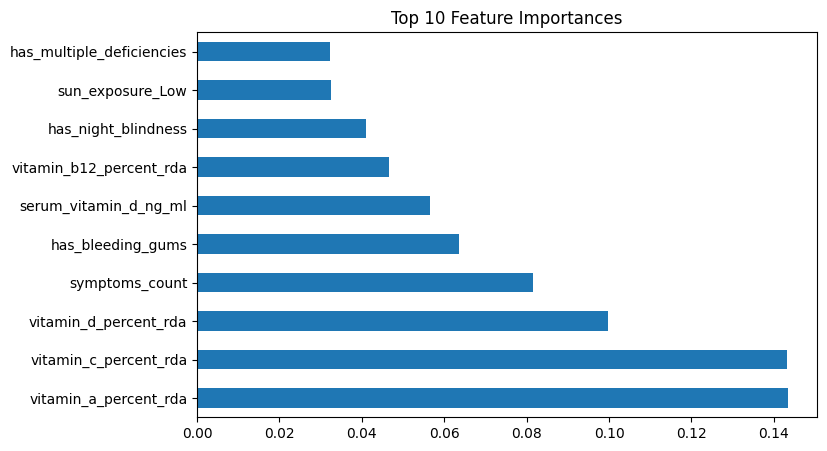

In [87]:
#-----FEATURE ANALYSIS-----#

importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False)

print("Top 10 important features:")
print(importances.head(10))


importances.head(10).plot(kind='barh', figsize=(8, 5), title='Top 10 Feature Importances')

In [88]:
#------SAVING MODEL------#

feature_columns = list(X_encoded.columns)
joblib.dump(feature_columns, 'feature_columns.pkl')
joblib.dump(model, 'best_model.pkl')
joblib.dump(label_encoder, 'encoder.pkl')

In [89]:
#------Download Files------#
from google.colab import files

files.download('best_model.pkl')
files.download('encoder.pkl')
files.download('feature_columns.pkl')